# 02 EDA dan Visualisasi Dataset

Notebook ini digunakan untuk melakukan Exploratory Data Analysis (EDA) pada dataset transaksi e-commerce Indonesia periode Januari 2024 sampai November 2025.

Tujuan notebook ini adalah:

1. Membaca dataset gabungan hasil Notebook 1.
2. Mengecek struktur data, missing value, dan statistik awal.
3. Menganalisis tren transaksi berdasarkan waktu.
4. Menganalisis kategori produk, wilayah, metode pembayaran, dan opsi pengiriman.
5. Membuat visualisasi untuk memahami pola data.

## Import Library

In [1]:
import warnings
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

## Inisialisasi Direktori Project

In [2]:
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name.lower() == "notebooks":
    BASE_DIR = CURRENT_DIR.parent
else:
    BASE_DIR = CURRENT_DIR

DATASET_DIR = BASE_DIR / "datasets"
COMBINED_DIR = DATASET_DIR / "combined"
RESULTS_DIR = BASE_DIR / "results"
EDA_DIR = RESULTS_DIR / "eda"

EDA_DIR.mkdir(parents=True, exist_ok=True)

combined_csv_path = COMBINED_DIR / "indonesia_ecommerce_sales_2024_2025_combined.csv"

print("Base directory    :", BASE_DIR)
print("Dataset path      :", combined_csv_path)
print("EDA result folder :", EDA_DIR)

Base directory    : e:\DOCUMENTS\PERKULIAHAN\SEMESTER 8\JOKI\TUGAS\Big Data\Tubes\code
Dataset path      : e:\DOCUMENTS\PERKULIAHAN\SEMESTER 8\JOKI\TUGAS\Big Data\Tubes\code\datasets\combined\indonesia_ecommerce_sales_2024_2025_combined.csv
EDA result folder : e:\DOCUMENTS\PERKULIAHAN\SEMESTER 8\JOKI\TUGAS\Big Data\Tubes\code\results\eda


## Membaca Dataset dengan Pandas

In [3]:
df = pd.read_csv(combined_csv_path)

print("Jumlah baris:", df.shape[0])
print("Jumlah kolom:", df.shape[1])

df.head()

Jumlah baris: 20404
Jumlah kolom: 27


,order_id,total_qty,total_weight_gr,total_returned_qty,Total Diskon,product_categories,num_product_categories,Status Pesanan,Alasan Pembatalan,Opsi Pengiriman,Metode Pembayaran,Kota/Kabupaten,Provinsi,Ongkos Kirim Dibayar oleh Pembeli,Estimasi Potongan Biaya Pengiriman,Total Pembayaran,Perkiraan Ongkos Kirim,Waktu Pesanan Dibuat,source_file,source_year,source_month,source_month_name,source_period,net_qty,is_cancelled,order_year,order_month
0,ORD_0006556,2,50,0,0,Aksesoris ID Card,1,Selesai,NaN,Hemat Kargo-SPX Hemat,Saldo ShopeePay,KAB. BEKASI,JAWA BARAT,0,8000,10000,8000,2024-01-01 00:05,JanuarySales2024_clean.xlsx,2024,1,Januari,2024-01,2,0,2024,1
1,ORD_0006557,2,1000,0,0,Celengan,1,Selesai,NaN,Hemat Kargo-SPX Hemat,COD (Bayar di Tempat),KOTA BANDUNG,JAWA BARAT,0,10000,35663,10000,2024-01-01 00:07,JanuarySales2024_clean.xlsx,2024,1,Januari,2024-01,2,0,2024,1
2,ORD_0006558,1,600,0,0,Plastik / Wadah Plastik,1,Selesai,NaN,Reguler (Cashless)-SPX Standard,COD (Bayar di Tempat),KAB. BOGOR,JAWA BARAT,0,10000,23187,10000,2024-01-01 00:07,JanuarySales2024_clean.xlsx,2024,1,Januari,2024-01,1,0,2024,1
3,ORD_0006559,1,700,0,0,Rak / Rak Serbaguna,1,Selesai,NaN,Hemat Kargo-SPX Hemat,COD (Bayar di Tempat),KOTA DEPOK,JAWA BARAT,0,8000,37400,8000,2024-01-01 00:12,JanuarySales2024_clean.xlsx,2024,1,Januari,2024-01,1,0,2024,1
4,ORD_0006560,1,500,0,0,Celengan,1,Selesai,NaN,Hemat Kargo-SPX Hemat,Online Payment,KAB. BEKASI,JAWA BARAT,0,8000,21800,8000,2024-01-01 00:36,JanuarySales2024_clean.xlsx,2024,1,Januari,2024-01,1,0,2024,1


## Mengecek Struktur Dataset

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20404 entries, 0 to 20403
Data columns (total 27 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   order_id                            20404 non-null  object
 1   total_qty                           20404 non-null  int64 
 2   total_weight_gr                     20404 non-null  int64 
 3   total_returned_qty                  20404 non-null  int64 
 4   Total Diskon                        20404 non-null  int64 
 5   product_categories                  20404 non-null  object
 6   num_product_categories              20404 non-null  int64 
 7   Status Pesanan                      20404 non-null  object
 8   Alasan Pembatalan                   2738 non-null   object
 9   Opsi Pengiriman                     20404 non-null  object
 10  Metode Pembayaran                   20404 non-null  object
 11  Kota/Kabupaten                      20404 non-null  ob

## Mengecek Missing Value

In [5]:
missing_values = df.isnull().sum().reset_index()
missing_values.columns = ["column", "missing_count"]
missing_values["missing_percentage"] = (missing_values["missing_count"] / len(df)) * 100

missing_values = missing_values.sort_values("missing_count", ascending=False)

missing_values.head(20)

,column,missing_count,missing_percentage
8,Alasan Pembatalan,17666,86.581063
17,Waktu Pesanan Dibuat,1980,9.703980
0,order_id,0,0.000000
14,Estimasi Potongan Biaya Pengiriman,0,0.000000
25,order_year,0,0.000000
24,is_cancelled,0,0.000000
23,net_qty,0,0.000000
22,source_period,0,0.000000
21,source_month_name,0,0.000000
20,source_month,0,0.000000


## Mengecek Duplikasi

In [6]:
duplicate_rows = df.duplicated().sum()

print("Jumlah baris duplikat:", duplicate_rows)

if "order_id" in df.columns:
    duplicate_order_id = df["order_id"].duplicated().sum()
    print("Jumlah duplikasi order_id:", duplicate_order_id)

Jumlah baris duplikat: 0
Jumlah duplikasi order_id: 0


## Ringkasan Statistik Numerik

In [7]:
numeric_columns = [
    "total_qty",
    "total_weight_gr",
    "total_returned_qty",
    "Total Diskon",
    "num_product_categories",
    "Ongkos Kirim Dibayar oleh Pembeli",
    "Estimasi Potongan Biaya Pengiriman",
    "Total Pembayaran",
    "Perkiraan Ongkos Kirim",
    "net_qty"
]

numeric_columns = [col for col in numeric_columns if col in df.columns]

df[numeric_columns].describe()

,total_qty,total_weight_gr,total_returned_qty,Total Diskon,num_product_categories,Ongkos Kirim Dibayar oleh Pembeli,Estimasi Potongan Biaya Pengiriman,Total Pembayaran,Perkiraan Ongkos Kirim,net_qty
count,20404.000000,20404.000000,20404.000000,20404.000000,20404.000000,20404.000000,20404.000000,2.040400e+04,20404.000000,20404.000000
mean,2.561998,2009.382719,0.018134,414.016663,1.111645,4086.332386,10840.496912,5.061760e+04,18424.159871,2.543864
std,7.861694,7161.302818,0.554587,9889.717663,0.485423,13507.052748,12713.400864,1.446010e+05,23862.751497,7.818901
min,1.000000,10.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000e+00,1.000000,0.000000
25%,1.000000,300.000000,0.000000,0.000000,1.000000,0.000000,3500.000000,1.348000e+04,8000.000000,1.000000
50%,1.000000,500.000000,0.000000,0.000000,1.000000,0.000000,9500.000000,2.159200e+04,11500.000000,1.000000
75%,2.000000,1600.000000,0.000000,0.000000,1.000000,2500.000000,15000.000000,4.156000e+04,20000.000000,2.000000
max,256.000000,375000.000000,70.000000,700000.000000,11.000000,584000.000000,312000.000000,3.403591e+06,959200.000000,256.000000


## Import dan Inisialisasi Spark

In [8]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col

spark = (
    SparkSession.builder
    .appName("EDA Indonesia E-Commerce Sales 2024-2025")
    .getOrCreate()
)

spark

## Membaca Dataset dengan PySpark

In [9]:
spark_df = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(str(combined_csv_path))
)

print("Jumlah baris Spark DataFrame:", spark_df.count())
print("Jumlah kolom Spark DataFrame:", len(spark_df.columns))

spark_df.printSchema()

Jumlah baris Spark DataFrame: 20404
Jumlah kolom Spark DataFrame: 27
root
 |-- order_id: string (nullable = true)
 |-- total_qty: integer (nullable = true)
 |-- total_weight_gr: integer (nullable = true)
 |-- total_returned_qty: integer (nullable = true)
 |-- Total Diskon: integer (nullable = true)
 |-- product_categories: string (nullable = true)
 |-- num_product_categories: integer (nullable = true)
 |-- Status Pesanan: string (nullable = true)
 |-- Alasan Pembatalan: string (nullable = true)
 |-- Opsi Pengiriman: string (nullable = true)
 |-- Metode Pembayaran: string (nullable = true)
 |-- Kota/Kabupaten: string (nullable = true)
 |-- Provinsi: string (nullable = true)
 |-- Ongkos Kirim Dibayar oleh Pembeli: integer (nullable = true)
 |-- Estimasi Potongan Biaya Pengiriman: integer (nullable = true)
 |-- Total Pembayaran: integer (nullable = true)
 |-- Perkiraan Ongkos Kirim: integer (nullable = true)
 |-- Waktu Pesanan Dibuat: timestamp (nullable = true)
 |-- source_file: string (

## Validasi Jumlah Data Pandas dan Spark

In [10]:
pandas_rows = df.shape[0]
spark_rows = spark_df.count()

print("Jumlah baris Pandas:", pandas_rows)
print("Jumlah baris Spark :", spark_rows)

if pandas_rows == spark_rows:
    print("Validasi berhasil: jumlah data Pandas dan Spark sama.")
else:
    print("Validasi perlu dicek: jumlah data berbeda.")

Jumlah baris Pandas: 20404
Jumlah baris Spark : 20404
Validasi berhasil: jumlah data Pandas dan Spark sama.


## Analisis 1: Tren Transaksi Bulanan

In [11]:
monthly_transactions = (
    df.groupby(["source_year", "source_month", "source_period"])
    .size()
    .reset_index(name="total_transactions")
    .sort_values(["source_year", "source_month"])
)

monthly_transactions

,source_year,source_month,source_period,total_transactions
0,2024,1,2024-01,431
1,2024,2,2024-02,389
2,2024,3,2024-03,453
3,2024,4,2024-04,492
4,2024,5,2024-05,620
5,2024,6,2024-06,697
6,2024,7,2024-07,1270
7,2024,8,2024-08,1293
8,2024,9,2024-09,1123
9,2024,10,2024-10,1217


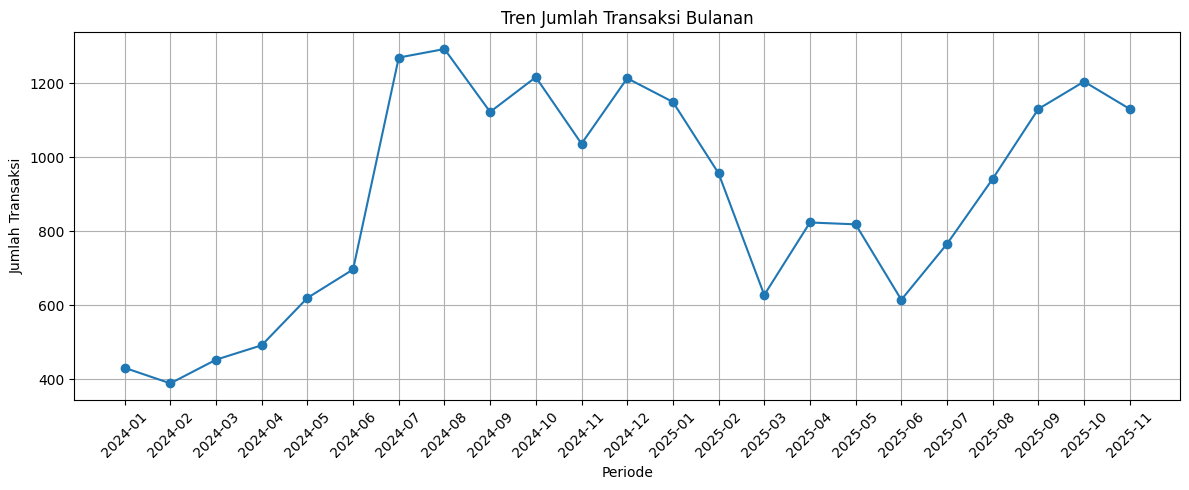

In [12]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_transactions["source_period"],
    monthly_transactions["total_transactions"],
    marker="o"
)

plt.title("Tren Jumlah Transaksi Bulanan")
plt.xlabel("Periode")
plt.ylabel("Jumlah Transaksi")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.savefig(EDA_DIR / "01_tren_transaksi_bulanan.png", dpi=300)
plt.show()

## Analisis 2: Top Kategori Produk Berdasarkan Demand

In [15]:
category_demand = (
    df.groupby("product_categories")
    .agg(
        total_transactions=("order_id", "count"),
        total_net_qty=("net_qty", "sum"),
        total_payment=("Total Pembayaran", "sum")
    )
    .reset_index()
    .sort_values("total_net_qty", ascending=False)
    .head(10)
)

category_demand

,product_categories,total_transactions,total_net_qty,total_payment
549,Nampan / Tray,1300,9783,97803810
495,Mangkok Sambal / Saus,3520,7965,126843159
323,Celengan,5342,7945,143695664
40,Aksesoris Pintu,2721,4515,35993608
480,Lunch Box / Rantang,522,3152,46089838
660,Seal / Baut / Roof,652,2091,269505258
160,Baskom / Mangkok Besar,573,1443,33775592
430,Keranjang,493,1086,13595528
636,Piring,141,884,7854215
572,Other,493,802,36971577


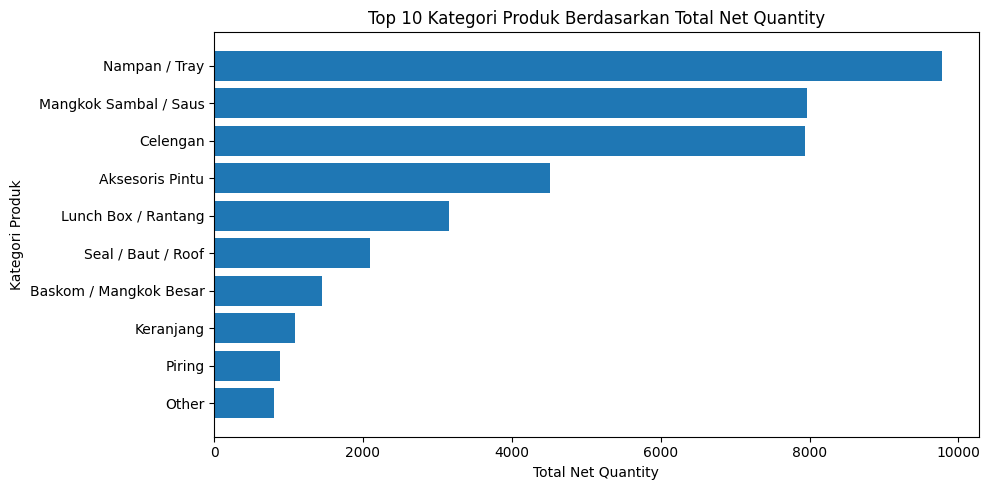

In [17]:
plt.figure(figsize=(10, 5))

plt.barh(
    category_demand["product_categories"],
    category_demand["total_net_qty"]
)

plt.title("Top 10 Kategori Produk Berdasarkan Total Net Quantity")
plt.xlabel("Total Net Quantity")
plt.ylabel("Kategori Produk")
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(EDA_DIR / "02_top_kategori_produk_demand.png", dpi=300)
plt.show()

## Analisis 3: Top Provinsi Berdasarkan Transaksi

In [18]:
province_transactions = (
    df.groupby("Provinsi")
    .agg(
        total_transactions=("order_id", "count"),
        total_net_qty=("net_qty", "sum"),
        total_payment=("Total Pembayaran", "sum")
    )
    .reset_index()
    .sort_values("total_transactions", ascending=False)
    .head(10)
)

province_transactions

,Provinsi,total_transactions,total_net_qty,total_payment
8,JAWA BARAT,6497,13412,269781809
2,BANTEN,3528,8179,173003408
5,DKI JAKARTA,2811,7967,129361547
10,JAWA TIMUR,1587,3838,95136526
9,JAWA TENGAH,1477,3515,98998875
32,SUMATERA SELATAN,625,4660,40218924
17,LAMPUNG,483,1301,21945012
7,JAMBI,338,830,15491461
25,RIAU,333,852,14731507
33,SUMATERA UTARA,306,727,19577496


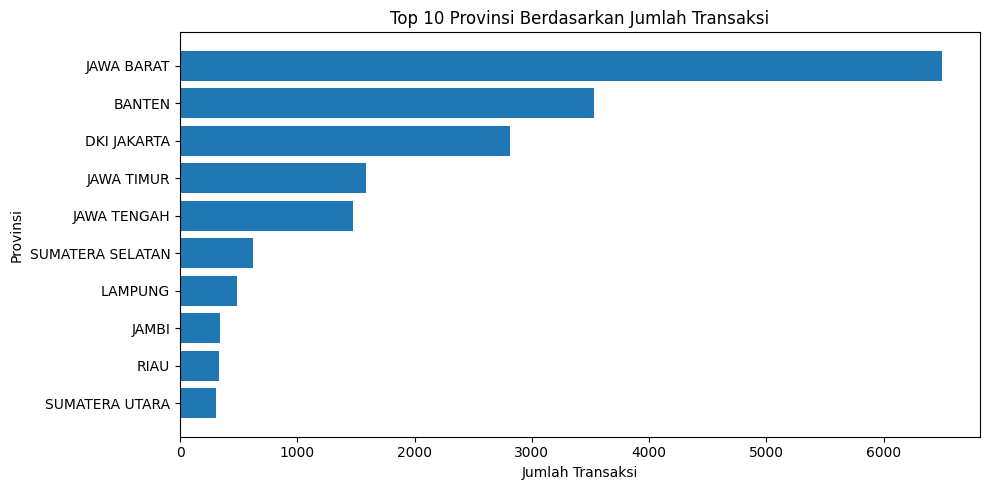

In [20]:
plt.figure(figsize=(10, 5))

plt.barh(
    province_transactions["Provinsi"],
    province_transactions["total_transactions"]
)

plt.title("Top 10 Provinsi Berdasarkan Jumlah Transaksi")
plt.xlabel("Jumlah Transaksi")
plt.ylabel("Provinsi")
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(EDA_DIR / "03_top_provinsi_transaksi.png", dpi=300)
plt.show()

## Analisis 4: Metode Pembayaran dan Opsi Pengiriman

In [21]:
payment_summary = (
    df["Metode Pembayaran"]
    .value_counts()
    .head(10)
    .reset_index()
)

payment_summary.columns = ["Metode Pembayaran", "total_transactions"]

payment_summary

,Metode Pembayaran,total_transactions
0,COD (Bayar di Tempat),11332
1,Saldo ShopeePay,3599
2,Online Payment,3109
3,SPayLater,1456
4,SeaBank Bayar Instan,584
5,Kartu Kredit/Debit,222
6,Indomaret/i.Saku,42
7,Alfamart/Alfamidi/Dan+Dan,35
8,Pembayaran dibebaskan,18
9,BCA OneKlik,3


In [22]:
shipping_summary = (
    df["Opsi Pengiriman"]
    .value_counts()
    .head(10)
    .reset_index()
)

shipping_summary.columns = ["Opsi Pengiriman", "total_transactions"]

shipping_summary

,Opsi Pengiriman,total_transactions
0,Hemat Kargo-SPX Hemat,12306
1,Reguler (Cashless)-SPX Standard,4587
2,SPX Hemat,543
3,Hemat Kargo,433
4,Reguler (Cashless)-JNE Reguler,340
5,Instant (Versi Lama)-SPX Instant (Versi Lama),327
6,Same Day-SPX Sameday,302
7,SPX Standard,192
8,Reguler (Cashless),184
9,Kargo-JNE Trucking (JTR),173


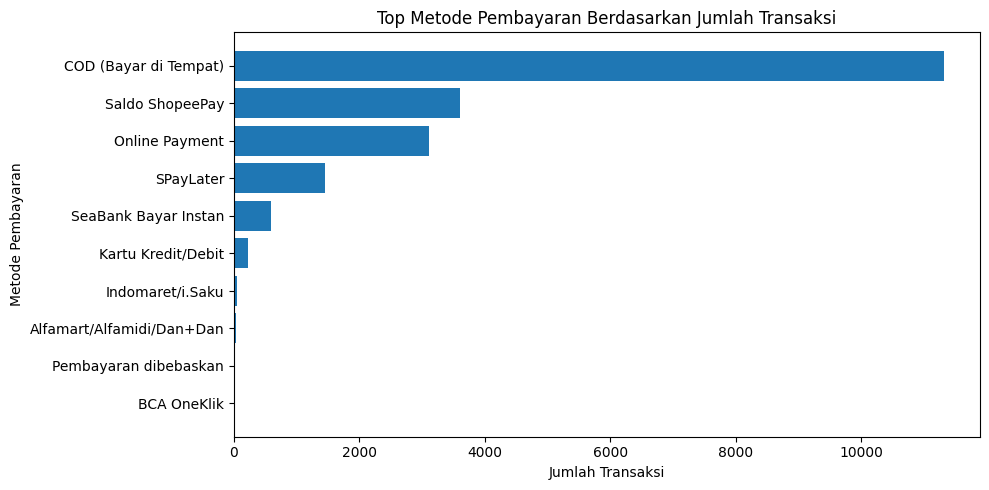

In [23]:
plt.figure(figsize=(10, 5))

plt.barh(
    payment_summary["Metode Pembayaran"],
    payment_summary["total_transactions"]
)

plt.title("Top Metode Pembayaran Berdasarkan Jumlah Transaksi")
plt.xlabel("Jumlah Transaksi")
plt.ylabel("Metode Pembayaran")
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(EDA_DIR / "04_top_metode_pembayaran.png", dpi=300)
plt.show()

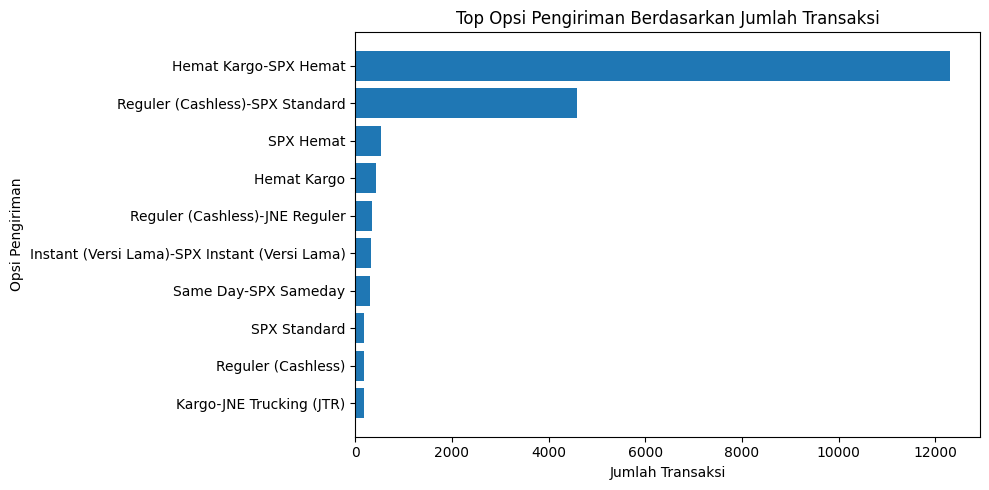

In [24]:
plt.figure(figsize=(10, 5))

plt.barh(
    shipping_summary["Opsi Pengiriman"],
    shipping_summary["total_transactions"]
)

plt.title("Top Opsi Pengiriman Berdasarkan Jumlah Transaksi")
plt.xlabel("Jumlah Transaksi")
plt.ylabel("Opsi Pengiriman")
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(EDA_DIR / "05_top_opsi_pengiriman.png", dpi=300)
plt.show()

## Correlation Heatmap Fitur Numerik

In [25]:
numeric_columns = [
    "total_qty",
    "total_weight_gr",
    "total_returned_qty",
    "Total Diskon",
    "num_product_categories",
    "Ongkos Kirim Dibayar oleh Pembeli",
    "Estimasi Potongan Biaya Pengiriman",
    "Total Pembayaran",
    "Perkiraan Ongkos Kirim",
    "net_qty"
]

numeric_columns = [col for col in numeric_columns if col in df.columns]

correlation_matrix = df[numeric_columns].corr()

correlation_matrix

,total_qty,total_weight_gr,total_returned_qty,Total Diskon,num_product_categories,Ongkos Kirim Dibayar oleh Pembeli,Estimasi Potongan Biaya Pengiriman,Total Pembayaran,Perkiraan Ongkos Kirim,net_qty
total_qty,1.000000,0.476564,0.112223,0.720294,0.086110,0.245309,0.196888,0.334770,0.358799,0.997513
total_weight_gr,0.476564,1.000000,0.085872,0.200933,0.323279,0.226053,0.223456,0.394215,0.404625,0.473081
total_returned_qty,0.112223,0.085872,1.000000,-0.000597,0.029438,0.029228,0.004457,0.028821,0.024033,0.041909
Total Diskon,0.720294,0.200933,-0.000597,1.000000,-0.008788,0.178470,0.105442,0.225151,0.211652,0.724279
num_product_categories,0.086110,0.323279,0.029438,-0.008788,1.000000,0.017060,0.068747,0.031670,0.054210,0.084493
Ongkos Kirim Dibayar oleh Pembeli,0.245309,0.226053,0.029228,0.178470,0.017060,1.000000,0.180827,0.455550,0.618061,0.244578
Estimasi Potongan Biaya Pengiriman,0.196888,0.223456,0.004457,0.105442,0.068747,0.180827,1.000000,0.488763,0.509856,0.197650
Total Pembayaran,0.334770,0.394215,0.028821,0.225151,0.031670,0.455550,0.488763,1.000000,0.466887,0.334558
Perkiraan Ongkos Kirim,0.358799,0.404625,0.024033,0.211652,0.054210,0.618061,0.509856,0.466887,1.000000,0.359058
net_qty,0.997513,0.473081,0.041909,0.724279,0.084493,0.244578,0.197650,0.334558,0.359058,1.000000


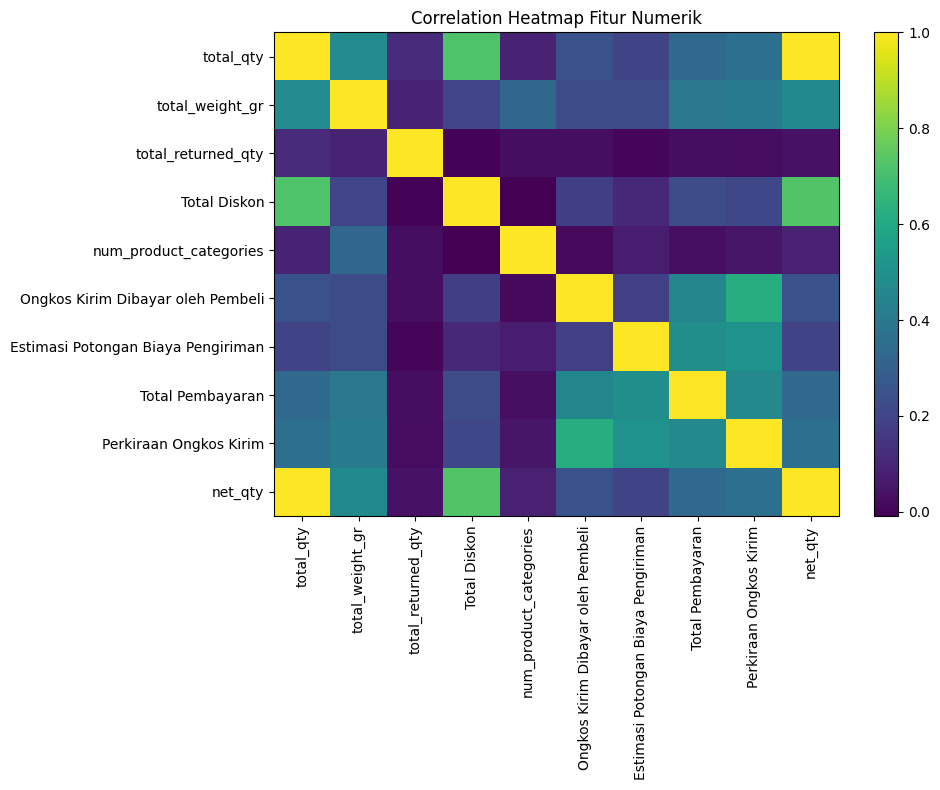

In [27]:
plt.figure(figsize=(10, 8))

plt.imshow(correlation_matrix, aspect="auto")
plt.colorbar()

plt.xticks(
    ticks=range(len(correlation_matrix.columns)),
    labels=correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    ticks=range(len(correlation_matrix.index)),
    labels=correlation_matrix.index
)

plt.title("Correlation Heatmap Fitur Numerik")
plt.tight_layout()

plt.savefig(EDA_DIR / "06_correlation_heatmap.png", dpi=300)
plt.show()

## Analisis Ringkas dengan PySpark

In [28]:
print("Agregasi transaksi per bulan menggunakan PySpark")

(
    spark_df
    .groupBy("source_year", "source_month", "source_period")
    .count()
    .orderBy("source_year", "source_month")
    .show(30, truncate=False)
)

Agregasi transaksi per bulan menggunakan PySpark
+-----------+------------+-------------------+-----+
|source_year|source_month|source_period      |count|
+-----------+------------+-------------------+-----+
|2024       |1           |2024-01-01 00:00:00|431  |
|2024       |2           |2024-02-01 00:00:00|389  |
|2024       |3           |2024-03-01 00:00:00|453  |
|2024       |4           |2024-04-01 00:00:00|492  |
|2024       |5           |2024-05-01 00:00:00|620  |
|2024       |6           |2024-06-01 00:00:00|697  |
|2024       |7           |2024-07-01 00:00:00|1270 |
|2024       |8           |2024-08-01 00:00:00|1293 |
|2024       |9           |2024-09-01 00:00:00|1123 |
|2024       |10          |2024-10-01 00:00:00|1217 |
|2024       |11          |2024-11-01 00:00:00|1037 |
|2024       |12          |2024-12-01 00:00:00|1214 |
|2025       |1           |2025-01-01 00:00:00|1150 |
|2025       |2           |2025-02-01 00:00:00|957  |
|2025       |3           |2025-03-01 00:00:00|628 

In [29]:
print("Top kategori produk menggunakan PySpark")

(
    spark_df
    .groupBy("product_categories")
    .count()
    .orderBy(col("count").desc())
    .show(10, truncate=False)
)

Top kategori produk menggunakan PySpark
+----------------------+-----+
|product_categories    |count|
+----------------------+-----+
|Celengan              |5342 |
|Mangkok Sambal / Saus |3520 |
|Aksesoris Pintu       |2721 |
|Nampan / Tray         |1300 |
|Seal / Baut / Roof    |652  |
|Baskom / Mangkok Besar|573  |
|Rak / Rak Serbaguna   |568  |
|Lunch Box / Rantang   |522  |
|Other                 |493  |
|Keranjang             |493  |
+----------------------+-----+
only showing top 10 rows


In [30]:
print("Top provinsi menggunakan PySpark")

(
    spark_df
    .groupBy("Provinsi")
    .count()
    .orderBy(col("count").desc())
    .show(10, truncate=False)
)

Top provinsi menggunakan PySpark
+----------------+-----+
|Provinsi        |count|
+----------------+-----+
|JAWA BARAT      |6497 |
|BANTEN          |3528 |
|DKI JAKARTA     |2811 |
|JAWA TIMUR      |1587 |
|JAWA TENGAH     |1477 |
|SUMATERA SELATAN|625  |
|LAMPUNG         |483  |
|JAMBI           |338  |
|RIAU            |333  |
|SUMATERA UTARA  |306  |
+----------------+-----+
only showing top 10 rows
